In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [3]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset\Training",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset\Testing",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


In [4]:
class_names = train_data.class_names
print("Classes:", class_names)

# Normalize pixel values
train_data = train_data.map(lambda x, y: (x/255.0, y))
test_data = test_data.map(lambda x, y: (x/255.0, y))

train_data = train_data.prefetch(buffer_size=tf.data.AUTOTUNE)
test_data = test_data.prefetch(buffer_size=tf.data.AUTOTUNE)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [17]:
model = models.Sequential([

    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    layers.Dense(4, activation='softmax')  # 4 classes
])

In [19]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 98s 537ms/step - accuracy: 0.7259 - loss: 0.6737 - val_accuracy: 0.7344 - val_loss: 0.9476
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 94s 537ms/step - accuracy: 0.8616 - loss: 0.3740 - val_accuracy: 0.7912 - val_loss: 0.7689
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 94s 533ms/step - accuracy: 0.9096 - loss: 0.2398 - val_accuracy: 0.8175 - val_loss: 0.9184
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 93s 528ms/step - accuracy: 0.9416 - loss: 0.1568 - val_accuracy: 0.8394 - val_loss: 0.7967
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 94s 534ms/step - accuracy: 0.9682 - loss: 0.0907 - val_accuracy: 0.8850 - val_loss: 0.8125
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 93s 530ms/step - accuracy: 0.9829 - loss: 0.0495 - val_accuracy: 0.8831 - val_loss: 1.0746
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 98s 557ms/step - accuracy: 0.9791 - loss: 0.0552 - val_accuracy: 0.8869 - val_loss: 0.9381
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 95s 540ms/step - accuracy: 0.9895 - loss: 0

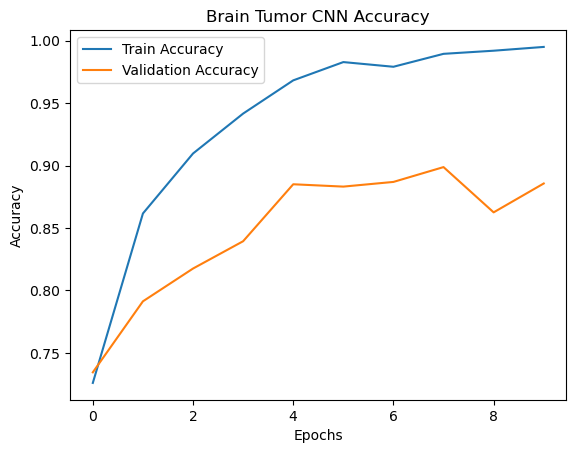

In [21]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Brain Tumor CNN Accuracy")
plt.show()

In [22]:
filters, biases = model.layers[0].get_weights()

# Normalize filters
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)


In [23]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy(), pred_index.numpy()

In [24]:
img_path = "dataset\Testing\glioma\Te-gl_10.jpg"  # change to any image

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array/255.0, axis=0)

heatmap, pred_class = get_gradcam_heatmap(
    model,
    img_array,
    last_conv_layer_name=model.layers[4].name
)

print("Predicted Class:", class_names[pred_class])

AttributeError: The layer sequential_1 has never been called and thus has no defined output.

In [15]:
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
plt.title(f"Grad-CAM: {class_names[pred_class]}")
plt.axis('off')
plt.show()

error: OpenCV(4.13.0) :-1: error: (-5:Bad argument) in function 'resize'
> Overload resolution failed:
>  - src is not a numpy array, neither a scalar
>  - Expected Ptr<cv::UMat> for argument 'src'


In [16]:
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 175ms/step - accuracy: 0.9013 - loss: 1.1361
Test Accuracy: 0.9012500047683716
